# Section 1. Configuration and Dependencies

In [ ]:
# =========================
# Base CONFIG
# =========================

RANDOM_STATE = 42
DEFAULT_ENCODING = "woe"        # default
DEFAULT_BALANCE  = "class_weight"
DEFAULT_DR       = "none"
DEFAULT_MODEL    = "xgb"        # main backbone

# Evaluation
N_SPLITS = 5
N_REPEATS = 5

# Stability
BOOTSTRAPS = 10
TOPK_LIST = [5, 10]

print("Config loaded.")


Config loaded.


Install dependencies

In [ ]:
!pip -q install -U imbalanced-learn shap xgboost pymoo category_encoders

# Optional blocks
# LightGBM:
!pip -q install -U lightgbm

# TabNet (optional block later)
!pip -q install pytorch-tabnet


import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import lightgbm as lgb

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from category_encoders.woe import WOEEncoder

import warnings
warnings.filterwarnings("ignore")

print("Imports done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
Imports done.


# Section 2. Data Loading and Dataset Registry

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

HEART_PATH = "/content/drive/MyDrive/CI Research/Datasets/Heart_disease_cleveland_303.csv"
DIAB_PATH  = "/content/drive/MyDrive/CI Research/Datasets/diabetes_768.csv"
CKD_PATH   = "/content/drive/MyDrive/CI Research/Datasets/kidney_disease_400.csv"

assert Path(HEART_PATH).exists(), "Heart CSV not found"
assert Path(DIAB_PATH).exists(),  "Diabetes CSV not found"
assert Path(CKD_PATH).exists(),   "CKD CSV not found"

heart_df = pd.read_csv(HEART_PATH)
diab_df  = pd.read_csv(DIAB_PATH)
ckd_df   = pd.read_csv(CKD_PATH)

print("Heart:", heart_df.shape)
print("Diabetes:", diab_df.shape)
print("CKD:", ckd_df.shape)

display(heart_df.head())
display(diab_df.head())
display(ckd_df.head())

Heart: (303, 14)
Diabetes: (768, 9)
CKD: (400, 26)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


# Section 3. Dataset Cleaning and Problem Setup

In [ ]:
import re

def clean_heart(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["target"] = df["target"].astype(int)

    # Treat these as categorical-coded (important for WOE/OneHot)
    cat_like = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
    for c in cat_like:
        if c in df.columns:
            df[c] = df[c].astype("category")
    return df

def clean_diabetes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Pima convention: 0 indicates missing for some clinical measurements
    zero_as_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
    for c in zero_as_missing:
        if c in df.columns:
            df.loc[df[c] == 0, c] = np.nan

    df["Outcome"] = df["Outcome"].astype(int)
    return df

def clean_ckd(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Strip/normalize strings
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()
            df[col] = df[col].replace({"?": np.nan, "nan": np.nan, "": np.nan})

    # Normalize target
    df["classification"] = (
        df["classification"].astype(str).str.lower().str.replace(r"\s+", "", regex=True)
    )
    df["classification"] = df["classification"].replace({"ckd": 1, "notckd": 0})
    df["classification"] = df["classification"].astype(int)

    # Coerce numeric-like object columns to numeric when appropriate
    for col in df.columns:
        if col == "classification":
            continue
        if df[col].dtype == "object":
            coerced = pd.to_numeric(df[col], errors="coerce")
            # if many values become numeric, treat as numeric
            if coerced.notna().mean() >= 0.30:
                df[col] = coerced
            else:
                df[col] = df[col].astype("category")

    return df

heart_df = clean_heart(heart_df)
diab_df  = clean_diabetes(diab_df)
ckd_df   = clean_ckd(ckd_df)

print("Targets distribution:")
print("Heart:", heart_df["target"].value_counts().to_dict())
print("Diabetes:", diab_df["Outcome"].value_counts().to_dict())
print("CKD:", ckd_df["classification"].value_counts().to_dict())

Targets distribution:
Heart: {0: 164, 1: 139}
Diabetes: {0: 500, 1: 268}
CKD: {1: 250, 0: 150}


Build X/y

In [ ]:
DATASETS = {
    "Heart": (heart_df.drop(columns=["target"]), heart_df["target"].astype(int)),
    "Diabetes": (diab_df.drop(columns=["Outcome"]), diab_df["Outcome"].astype(int)),
    "CKD": (ckd_df.drop(columns=["classification"]), ckd_df["classification"].astype(int)),
}

for name, (X, y) in DATASETS.items():
    print(f"{name}: X={X.shape}, y={y.shape}, pos_rate={y.mean():.3f}")

Heart: X=(303, 13), y=(303,), pos_rate=0.459
Diabetes: X=(768, 8), y=(768,), pos_rate=0.349
CKD: X=(400, 25), y=(400,), pos_rate=0.625


# Section 4. Leakage-Safe Preprocessing

In [ ]:
def split_cols(X: pd.DataFrame):
    cat_cols = [c for c in X.columns if str(X[c].dtype) in ("category", "object")]
    num_cols = [c for c in X.columns if c not in cat_cols]
    return num_cols, cat_cols

def build_preprocessor(X: pd.DataFrame, encoding="woe", scale_numeric=True):
    num_cols, cat_cols = split_cols(X)

    # numeric: median impute + missing indicators (+ scaling optional)
    num_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    # categorical: mode impute + WOE or OneHot
    if encoding == "onehot":
        cat_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
    elif encoding == "woe":
        cat_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("woe", WOEEncoder(random_state=RANDOM_STATE))
        ])
    else:
        raise ValueError("encoding must be 'woe' or 'onehot'")

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )
    return pre

Optional dimensionality reduction block (Ablation only)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def maybe_add_dim_reduction(dr="none"):
    if dr == "lda":
        return ("lda", LinearDiscriminantAnalysis())
    if dr == "none":
        return None
    raise ValueError("dr must be 'lda' or 'none'")


Models (XGBoost default + LightGBM optional)

In [ ]:
def get_model(model_name: str):
    if model_name == "lr":
        return LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)

    if model_name == "rf":
        return RandomForestClassifier(
            n_estimators=600,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if model_name == "xgb":
        return XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.1,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )

    if model_name == "lgbm":
        return lgb.LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    raise ValueError(f"Unknown model_name: {model_name}")


Imbalance handling through **class_weight** and **SMOTE**


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

def safe_smote(y, random_state=42):
    """
    Create a SMOTE object with a fold-safe k_neighbors value.
    Returns None if SMOTE is not feasible in a given class distribution.
    """
    y_arr = np.asarray(y)
    _, counts = np.unique(y_arr, return_counts=True)
    minority_count = counts.min()

    if minority_count <= 1:
        return None

    k = min(3, minority_count - 1)
    return SMOTE(random_state=random_state, k_neighbors=k)

def build_full_pipeline(X, y, encoding="woe", balance="class_weight", dr="none", model_name="xgb"):
    # scaling helpful for LR / LDA; tree models do not require it
    scale_numeric = True if (model_name in ["lr"] or dr == "lda") else False

    pre = build_preprocessor(X, encoding=encoding, scale_numeric=scale_numeric)
    steps = [("prep", pre)]

    dr_step = maybe_add_dim_reduction(dr)
    if dr_step is not None:
        steps.append(dr_step)

    clf = get_model(model_name)

    # imbalance handling
    if balance == "smote":
        sm = safe_smote(y, random_state=RANDOM_STATE)
        if sm is not None:
            steps.append(("smote", sm))

    elif balance == "class_weight":
        if model_name in ["lr", "rf"]:
            clf.set_params(class_weight="balanced")
        elif model_name == "xgb":
            pos = (y == 1).sum()
            neg = (y == 0).sum()
            if pos > 0:
                clf.set_params(scale_pos_weight=float(neg / pos))
        elif model_name == "lgbm":
            clf.set_params(is_unbalance=True)

    elif balance == "none":
        pass

    else:
        raise ValueError("balance must be 'smote' or 'class_weight' or 'none'")

    steps.append(("clf", clf))
    return ImbPipeline(steps=steps)


# Section 5. Baseline Model Development

In [ ]:
from itertools import product
from sklearn.metrics import average_precision_score, roc_auc_score, balanced_accuracy_score, f1_score
import numpy as np

def _get_scores_binary(estimator, X):
    """Return 1D score for the positive class."""
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] == 2:
            return proba[:, 1]
        return proba
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)

def auprc_scorer(estimator, X, y):
    y_score = _get_scores_binary(estimator, X)
    return average_precision_score(y, y_score)

def auroc_scorer(estimator, X, y):
    y_score = _get_scores_binary(estimator, X)
    return roc_auc_score(y, y_score)

def f1_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return f1_score(y, y_pred)

def balacc_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return balanced_accuracy_score(y, y_pred)

scoring = {
    "auroc": auroc_scorer,
    "auprc": auprc_scorer,
    "f1": f1_scorer,
    "bal_acc": balacc_scorer,
}

print("Custom scorers loaded.")

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

def eval_one(dataset_name, X, y, encoding, balance, dr, model_name):
    pipe = build_full_pipeline(X, y, encoding=encoding, balance=balance, dr=dr, model_name=model_name)
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

    return {
        "dataset": dataset_name,
        "encoding": encoding,
        "balance": balance,
        "dr": dr,
        "model": model_name,
        "AUROC_mean": np.mean(scores["test_auroc"]),
        "AUROC_std":  np.std(scores["test_auroc"]),
        "AUPRC_mean": np.mean(scores["test_auprc"]),
        "AUPRC_std":  np.std(scores["test_auprc"]),
        "F1_mean":    np.mean(scores["test_f1"]),
        "F1_std":     np.std(scores["test_f1"]),
        "BalAcc_mean": np.mean(scores["test_bal_acc"]),
        "BalAcc_std":  np.std(scores["test_bal_acc"]),
    }

def run_phase1_benchmarks():
    # Mainline grid used in the final study (LDA excluded from the mainline search)
    encodings = ["woe", "onehot"]
    balances = ["class_weight", "smote"]
    models = ["xgb", "lgbm", "rf", "lr"]

    configs = list(product(encodings, balances, ["none"], models))

    rows = []
    for ds_name, (X, y) in DATASETS.items():
        for enc, bal, dr, model in configs:
            rows.append(eval_one(ds_name, X, y, enc, bal, dr, model))

    res = pd.DataFrame(rows).sort_values(["dataset", "AUPRC_mean"], ascending=[True, False])
    return res

phase1_results = run_phase1_benchmarks()
phase1_results


Custom scorers loaded.


,dataset,encoding,balance,dr,model,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,BalAcc_mean,BalAcc_std
32,CKD,woe,class_weight,none,xgb,1.000000,0.000000e+00,1.000000,4.440892e-17,0.997632,0.005045,0.996000,0.008537
34,CKD,woe,class_weight,none,rf,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
36,CKD,woe,smote,none,xgb,1.000000,3.140185e-17,1.000000,0.000000e+00,0.997632,0.005045,0.996000,0.008537
37,CKD,woe,smote,none,lgbm,1.000000,0.000000e+00,1.000000,9.930137e-17,1.000000,0.000000,1.000000,0.000000
38,CKD,woe,smote,none,rf,1.000000,0.000000e+00,1.000000,6.280370e-17,1.000000,0.000000,1.000000,0.000000
40,CKD,onehot,class_weight,none,xgb,1.000000,2.220446e-17,1.000000,2.220446e-17,0.997632,0.005045,0.996000,0.008537
42,CKD,onehot,class_weight,none,rf,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000,1.000000,0.000000
44,CKD,onehot,smote,none,xgb,1.000000,0.000000e+00,1.000000,2.220446e-17,0.997632,0.005045,0.996000,0.008537
45,CKD,onehot,smote,none,lgbm,1.000000,0.000000e+00,1.000000,1.174950e-16,1.000000,0.000000,1.000000,0.000000
46,CKD,onehot,smote,none,rf,1.000000,0.000000e+00,1.000000,4.965068e-17,1.000000,0.000000,1.000000,0.000000


Drop ID column in CKD (leakage/meaningless feature)

In [ ]:
DROP_ID_CKD = True

if DROP_ID_CKD and "CKD" in DATASETS:
    X_ckd, y_ckd = DATASETS["CKD"]
    if "id" in X_ckd.columns:
        DATASETS["CKD"] = (X_ckd.drop(columns=["id"]), y_ckd)
        print("Dropped CKD 'id' column.")

Dropped CKD 'id' column.


Auto-pick the best configs (XGB only vs XGB+LGBM)

In [ ]:
def best_config_table(res: pd.DataFrame, allow_models=None, metric="AUPRC_mean"):
    df = res.copy()
    if allow_models is not None:
        df = df[df["model"].isin(allow_models)]
    # pick best per dataset by metric
    idx = df.groupby("dataset")[metric].idxmax()
    return df.loc[idx].sort_values("dataset")

best_xgb_only  = best_config_table(phase1_results, allow_models=["xgb"], metric="AUPRC_mean")
best_xgb_lgbm  = best_config_table(phase1_results, allow_models=["xgb","lgbm"], metric="AUPRC_mean")

print("Best (XGB-only):")
display(best_xgb_only)

print("Best (XGB + LGBM):")
display(best_xgb_lgbm)

Best (XGB-only):


,dataset,encoding,balance,dr,model,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,BalAcc_mean,BalAcc_std
32,CKD,woe,class_weight,none,xgb,1.000000,0.000000,1.000000,4.440892e-17,0.997632,0.005045,0.996000,0.008537
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.031686,0.695401,5.661053e-02,0.661766,0.043065,0.738838,0.034339
12,Heart,onehot,smote,none,xgb,0.886573,0.032247,0.886260,3.150156e-02,0.795100,0.052110,0.814116,0.044986


Best (XGB + LGBM):


,dataset,encoding,balance,dr,model,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,BalAcc_mean,BalAcc_std
32,CKD,woe,class_weight,none,xgb,1.000000,0.000000,1.000000,4.440892e-17,0.997632,0.005045,0.996000,0.008537
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.031686,0.695401,5.661053e-02,0.661766,0.043065,0.738838,0.034339
12,Heart,onehot,smote,none,xgb,0.886573,0.032247,0.886260,3.150156e-02,0.795100,0.052110,0.814116,0.044986


# Baseline Result Visualization

Dataset class distribution figure

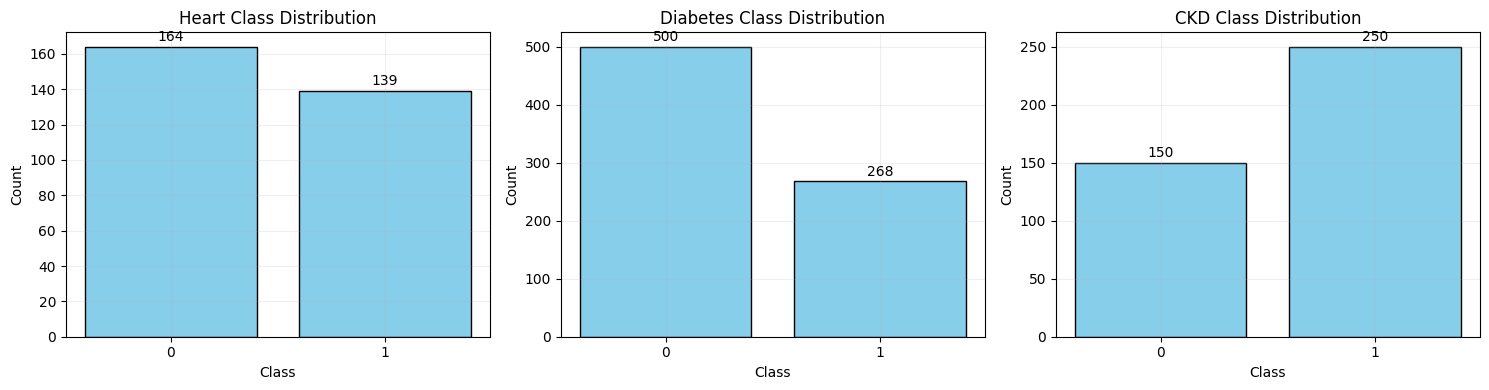

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (X, y)) in zip(axes, DATASETS.items()):
    counts = y.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="skyblue", edgecolor="black")
    ax.set_title(f"{name} Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.02, str(v), ha="center", fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("dataset_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Missing values overview figure


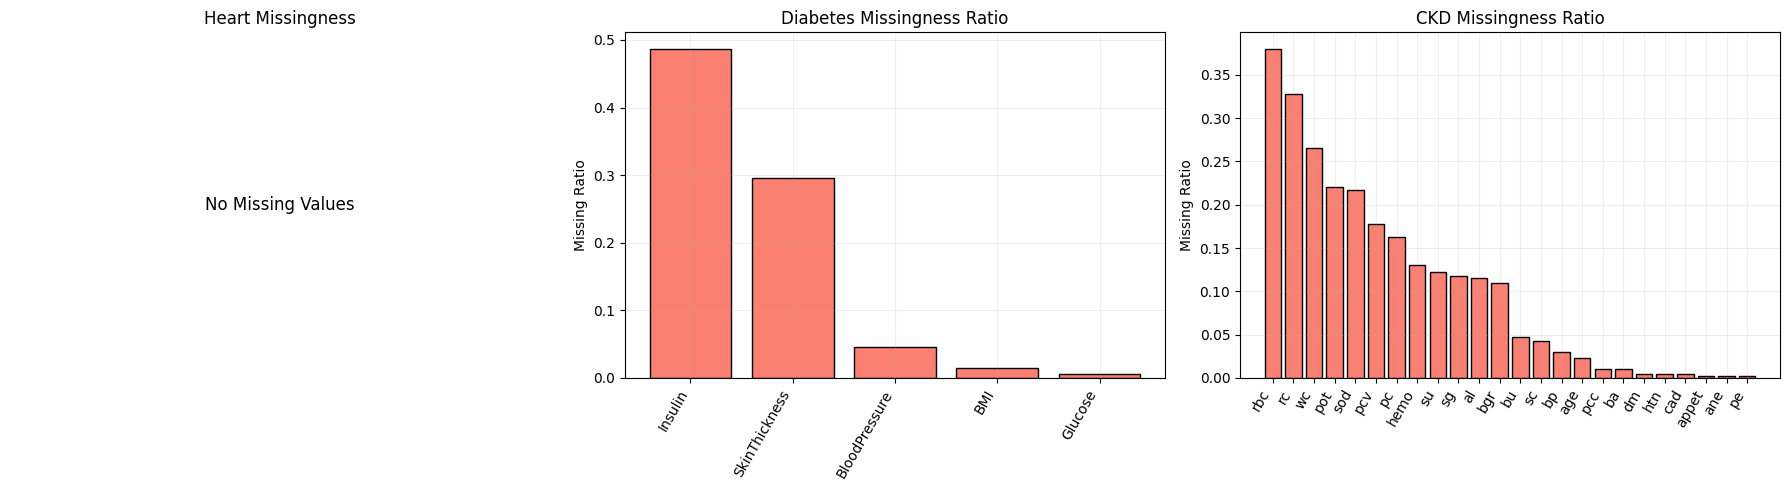

In [ ]:
def plot_missingness(df_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, df) in zip(axes, df_dict.items()):
        miss = df.isnull().mean().sort_values(ascending=False)
        miss = miss[miss > 0]

        if len(miss) == 0:
            ax.text(0.5, 0.5, "No Missing Values", ha="center", va="center", fontsize=12)
            ax.set_title(f"{name} Missingness")
            ax.axis("off")
        else:
            ax.bar(miss.index, miss.values, color="salmon", edgecolor="black")
            ax.set_title(f"{name} Missingness Ratio")
            ax.set_ylabel("Missing Ratio")
            ax.set_xticklabels(miss.index, rotation=60, ha="right")
            ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig("missingness_overview.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_missingness({
    "Heart": heart_df,
    "Diabetes": diab_df,
    "CKD": ckd_df
})

Compare preprocessing strategies

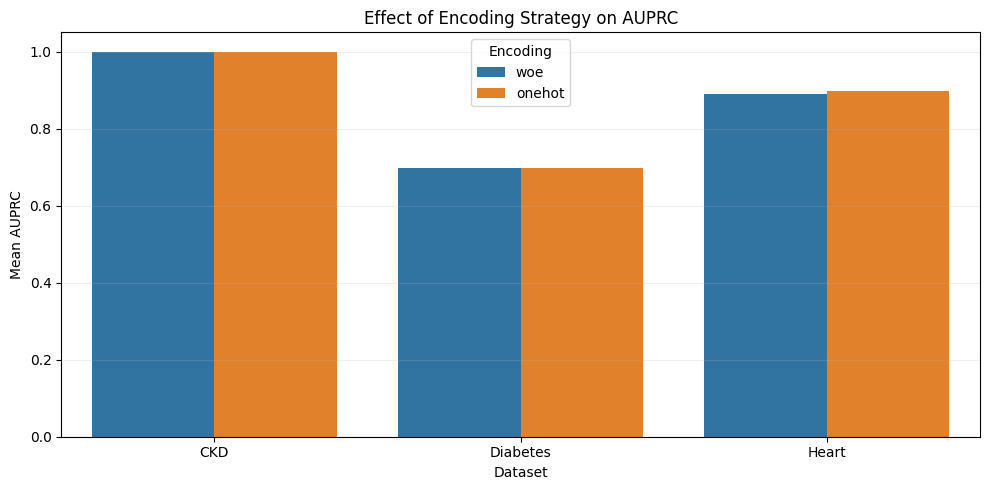

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=phase1_results,
    x="dataset",
    y="AUPRC_mean",
    hue="encoding",
    errorbar=None
)
plt.title("Effect of Encoding Strategy on AUPRC")
plt.ylabel("Mean AUPRC")
plt.xlabel("Dataset")
plt.legend(title="Encoding")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("encoding_effect_auprc.png", dpi=300, bbox_inches="tight")
plt.show()

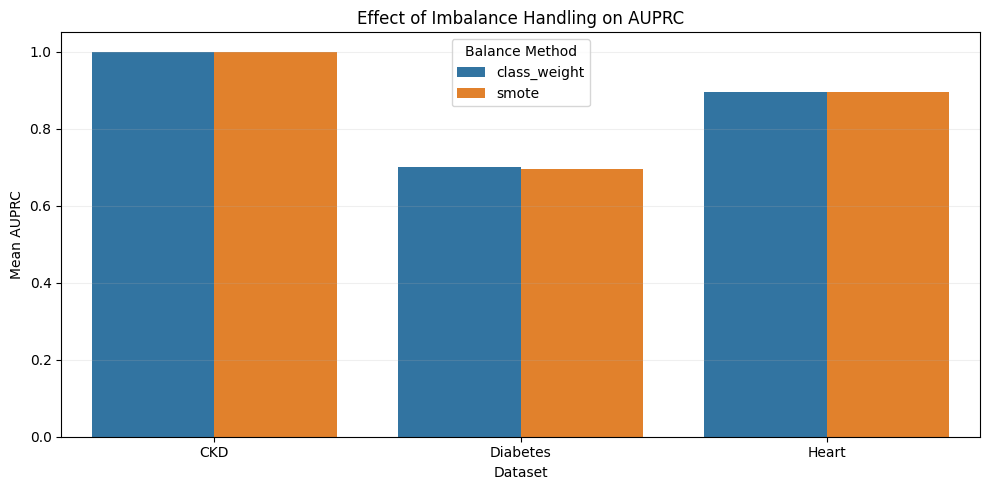

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=phase1_results,
    x="dataset",
    y="AUPRC_mean",
    hue="balance",
    errorbar=None
)
plt.title("Effect of Imbalance Handling on AUPRC")
plt.ylabel("Mean AUPRC")
plt.xlabel("Dataset")
plt.legend(title="Balance Method")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("balance_effect_auprc.png", dpi=300, bbox_inches="tight")
plt.show()

Baseline benchmark figure (AUROC)


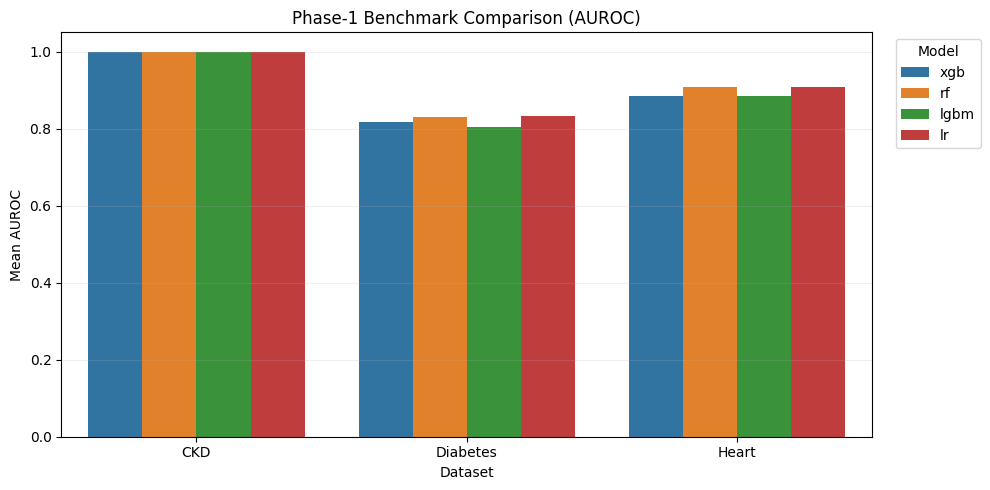

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(
    data=phase1_results,
    x="dataset",
    y="AUROC_mean",
    hue="model",
    errorbar=None
)
plt.title("Phase-1 Benchmark Comparison (AUROC)")
plt.ylabel("Mean AUROC")
plt.xlabel("Dataset")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("phase1_benchmark_auroc.png", dpi=300, bbox_inches="tight")
plt.show()

Baseline benchmark figure (AUPRC)

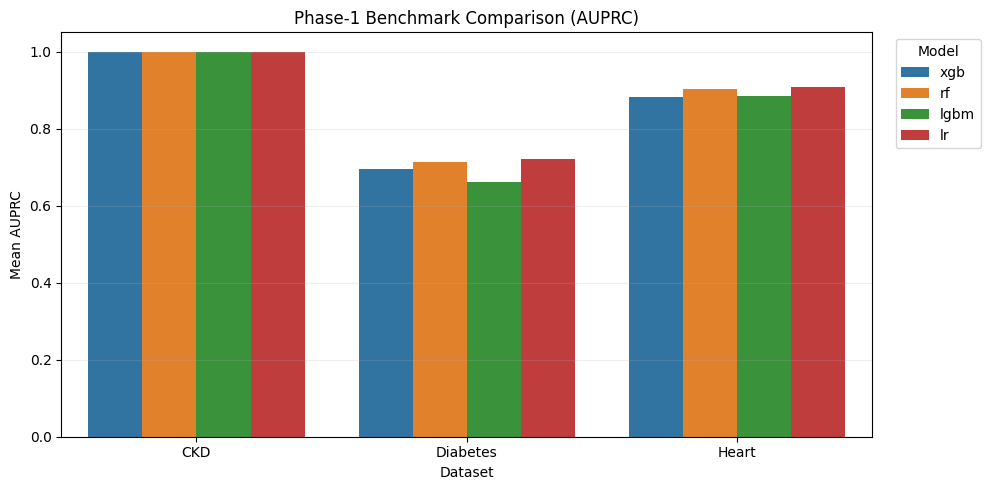

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=phase1_results,
    x="dataset",
    y="AUPRC_mean",
    hue="model",
    errorbar=None
)
plt.title("Phase-1 Benchmark Comparison (AUPRC)")
plt.ylabel("Mean AUPRC")
plt.xlabel("Dataset")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("phase1_benchmark_auprc.png", dpi=300, bbox_inches="tight")
plt.show()

Baseline predictive performance across datasets

Final Baseline Performance Table


,Dataset,Encoding,Balance,DR,Model,AUROC,AUPRC,AUPRC_std,BalancedAcc
32,CKD,woe,class_weight,none,xgb,1.000000,1.000000,4.440892e-17,0.996000
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.695401,5.661053e-02,0.738838
12,Heart,onehot,smote,none,xgb,0.886573,0.886260,3.150156e-02,0.814116


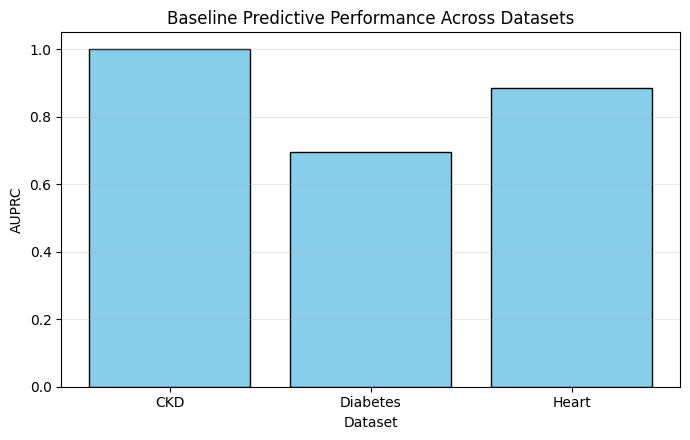

In [ ]:
# Baseline predictive performance
# F1. Final compact summary tables

import pandas as pd
from IPython.display import display

# -----------------------------
# Final performance table
# -----------------------------
if "best_xgb_only" in globals() and not best_xgb_only.empty:
    final_phase1_table = best_xgb_only.copy()

    # standardize columns
    rename_map = {}
    if "dataset" in final_phase1_table.columns:
        rename_map["dataset"] = "Dataset"
    if "AUPRC_mean" in final_phase1_table.columns:
        rename_map["AUPRC_mean"] = "AUPRC"
    if "AUROC_mean" in final_phase1_table.columns:
        rename_map["AUROC_mean"] = "AUROC"
    if "BalAcc_mean" in final_phase1_table.columns:
        rename_map["BalAcc_mean"] = "BalancedAcc"

    final_phase1_table = final_phase1_table.rename(columns=rename_map)

    keep_cols = [c for c in ["Dataset", "encoding", "balance", "dr", "model", "AUROC", "AUPRC", "AUPRC_std", "BalancedAcc"] if c in final_phase1_table.columns]
    final_phase1_table = final_phase1_table[keep_cols].copy()

    # prettify names
    final_phase1_table = final_phase1_table.rename(columns={
        "encoding": "Encoding",
        "balance": "Balance",
        "dr": "DR",
        "model": "Model"
    })

    print("Final Baseline Performance Table")
    display(final_phase1_table)

import matplotlib.pyplot as plt

if "final_phase1_table" not in globals() or final_phase1_table.empty:
    raise ValueError("final_phase1_table not found. Run F1 first.")

plt.figure(figsize=(7, 4.5))
plt.bar(final_phase1_table["Dataset"], final_phase1_table["AUPRC"],
        color="skyblue", edgecolor="black")
plt.title("Baseline Predictive Performance Across Datasets")
plt.ylabel("AUPRC")
plt.xlabel("Dataset")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("baseline_auprc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Best configuration summary plot

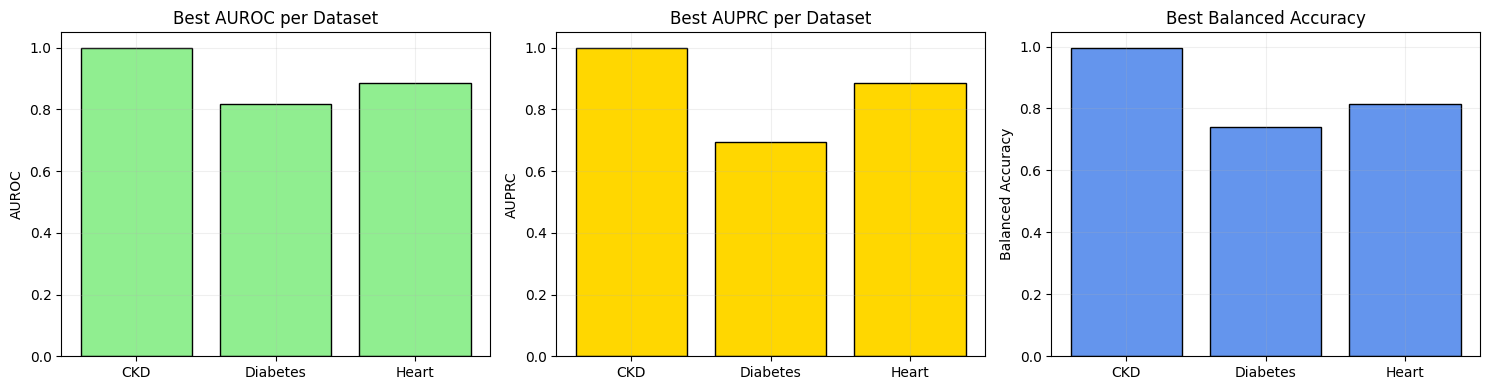

In [ ]:
best_plot = best_xgb_only.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(best_plot["dataset"], best_plot["AUROC_mean"], color="lightgreen", edgecolor="black")
axes[0].set_title("Best AUROC per Dataset")
axes[0].set_ylabel("AUROC")
axes[0].grid(alpha=0.2)

axes[1].bar(best_plot["dataset"], best_plot["AUPRC_mean"], color="gold", edgecolor="black")
axes[1].set_title("Best AUPRC per Dataset")
axes[1].set_ylabel("AUPRC")
axes[1].grid(alpha=0.2)

axes[2].bar(best_plot["dataset"], best_plot["BalAcc_mean"], color="cornflowerblue", edgecolor="black")
axes[2].set_title("Best Balanced Accuracy")
axes[2].set_ylabel("Balanced Accuracy")
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("best_config_summary.png", dpi=300, bbox_inches="tight")
plt.show()

Best Configurations per Dataset

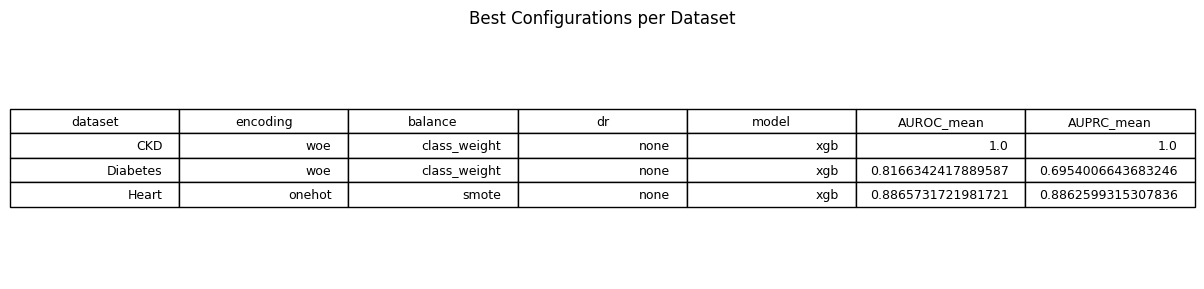

In [ ]:
import matplotlib.pyplot as plt

def save_table_as_image(df, filename, title=None, figsize=(12, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.1, 1.4)
    if title:
        plt.title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

save_table_as_image(
    best_xgb_only[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean"]],
    "best_config_table.png",
    title="Best Configurations per Dataset"
)

Consistency protocol table for baseline

In [ ]:

# Shared XGBoost consistency protocol table
shared_xgb_protocol = phase1_results[phase1_results["model"] == "xgb"].copy()
shared_xgb_protocol = (
    shared_xgb_protocol.sort_values(["dataset","AUPRC_mean"], ascending=[True,False])
    .groupby("dataset")
    .head(1)
    .sort_values("dataset")
)

print("Dataset-specific best configuration:")
display(best_xgb_only[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean","AUPRC_std","BalAcc_mean"]])

print("Shared XGBoost consistency protocol:")
display(shared_xgb_protocol[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean","AUPRC_std","BalAcc_mean"]])

shared_xgb_protocol.to_csv("shared_xgb_protocol.csv", index=False)


Dataset-specific best configuration:


,dataset,encoding,balance,dr,model,AUROC_mean,AUPRC_mean,AUPRC_std,BalAcc_mean
32,CKD,woe,class_weight,none,xgb,1.000000,1.000000,4.440892e-17,0.996000
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.695401,5.661053e-02,0.738838
12,Heart,onehot,smote,none,xgb,0.886573,0.886260,3.150156e-02,0.814116


Shared XGBoost consistency protocol:


,dataset,encoding,balance,dr,model,AUROC_mean,AUPRC_mean,AUPRC_std,BalAcc_mean
32,CKD,woe,class_weight,none,xgb,1.000000,1.000000,4.440892e-17,0.996000
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.695401,5.661053e-02,0.738838
12,Heart,onehot,smote,none,xgb,0.886573,0.886260,3.150156e-02,0.814116


# Section 6. SHAP Stability Analysis

In [ ]:
import shap
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

def fit_one_split_best(X, y, cfg, train_idx, test_idx):
    enc, bal, dr, model = cfg["encoding"], cfg["balance"], cfg["dr"], cfg["model"]
    pipe = build_full_pipeline(X, y, encoding=enc, balance=bal, dr=dr, model_name=model)
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    return pipe

def get_shap_topk(pipe, X_sample, topk=10):
    # get fitted classifier from pipeline
    clf = pipe.named_steps["clf"]
    # transform features up to classifier input
    Xt = pipe.named_steps["prep"].transform(X_sample)

    # If LDA exists, apply it before SHAP (note: SHAP on LDA space is less interpretable)
    if "lda" in pipe.named_steps:
        Xt = pipe.named_steps["lda"].transform(Xt)

    # TreeExplainer works best for xgb/lgbm
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(Xt)

    # Binary: shap_values may return list or array depending on version
    if isinstance(sv, list):
        sv = sv[1]  # positive class

    mean_abs = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:topk]
    return top_idx, mean_abs[top_idx]

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / max(1, len(a | b))

def shap_stability_bootstrap(dataset_name, cfg_row, B=10, topk=10, sample_n=200):
    X, y = DATASETS[dataset_name]
    cfg = cfg_row.iloc[0].to_dict()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, test_idx = next(skf.split(X, y))

    rng = np.random.RandomState(RANDOM_STATE)
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    top_sets = []
    for b in range(B):
        boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        Xb = X_train.iloc[boot_idx]
        yb = y_train.iloc[boot_idx]

        pipe = build_full_pipeline(X, y, encoding=cfg["encoding"], balance=cfg["balance"], dr=cfg["dr"], model_name=cfg["model"])
        pipe.fit(Xb, yb)

        # sample for shap (speed)
        samp_idx = rng.choice(len(Xb), size=min(sample_n, len(Xb)), replace=False)
        top_idx, _ = get_shap_topk(pipe, Xb.iloc[samp_idx], topk=topk)
        top_sets.append(top_idx)

    # pairwise jaccard
    J = []
    for i in range(len(top_sets)):
        for j in range(i+1, len(top_sets)):
            J.append(jaccard(top_sets[i], top_sets[j]))
    return float(np.mean(J)), float(np.std(J))

# Run stability on best configs (XGB-only and XGB+LGBM)
def run_shap_stability(best_table, topk=10, B=10):
    rows = []
    for ds in best_table["dataset"].unique():
        cfg_row = best_table[best_table["dataset"] == ds]
        meanJ, stdJ = shap_stability_bootstrap(ds, cfg_row, B=B, topk=topk)
        r = cfg_row.iloc[0].to_dict()
        r["TopK"] = topk
        r["Jaccard_mean"] = meanJ
        r["Jaccard_std"] = stdJ
        rows.append(r)
    return pd.DataFrame(rows).sort_values("dataset")

stab_xgb  = run_shap_stability(best_xgb_only, topk=10, B=BOOTSTRAPS)
stab_xl   = run_shap_stability(best_xgb_lgbm, topk=10, B=BOOTSTRAPS)

print("SHAP Stability (XGB-only):")
display(stab_xgb)

print("SHAP Stability (XGB+LGBM):")
display(stab_xl)

SHAP Stability (XGB-only):


,dataset,encoding,balance,dr,model,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,BalAcc_mean,BalAcc_std,TopK,Jaccard_mean,Jaccard_std
0,CKD,woe,class_weight,none,xgb,1.000000,0.000000,1.000000,4.440892e-17,0.997632,0.005045,0.996000,0.008537,10,0.718208,0.082138
1,Diabetes,woe,class_weight,none,xgb,0.816634,0.031686,0.695401,5.661053e-02,0.661766,0.043065,0.738838,0.034339,10,0.907071,0.090887
2,Heart,onehot,smote,none,xgb,0.886573,0.032247,0.886260,3.150156e-02,0.795100,0.052110,0.814116,0.044986,10,0.665964,0.117120


SHAP Stability (XGB+LGBM):


,dataset,encoding,balance,dr,model,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,F1_mean,F1_std,BalAcc_mean,BalAcc_std,TopK,Jaccard_mean,Jaccard_std
0,CKD,woe,class_weight,none,xgb,1.000000,0.000000,1.000000,4.440892e-17,0.997632,0.005045,0.996000,0.008537,10,0.718208,0.082138
1,Diabetes,woe,class_weight,none,xgb,0.816634,0.031686,0.695401,5.661053e-02,0.661766,0.043065,0.738838,0.034339,10,0.907071,0.090887
2,Heart,onehot,smote,none,xgb,0.886573,0.032247,0.886260,3.150156e-02,0.795100,0.052110,0.814116,0.044986,10,0.665964,0.117120


Model stability comparison figure

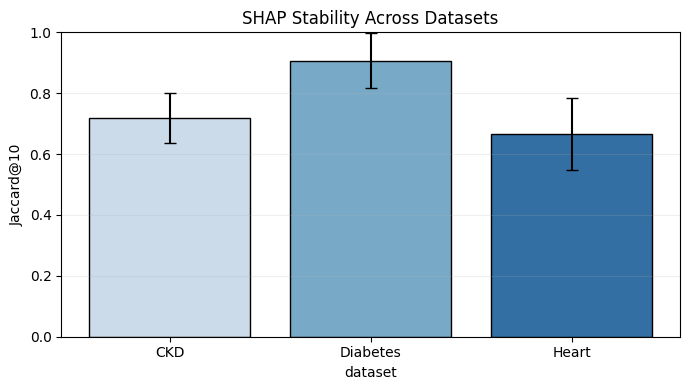

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=stab_xgb,
    x="dataset",
    y="Jaccard_mean",
    palette="Blues",
    edgecolor="black"
)
plt.errorbar(
    x=np.arange(len(stab_xgb)),
    y=stab_xgb["Jaccard_mean"],
    yerr=stab_xgb["Jaccard_std"],
    fmt='none',
    c='black',
    capsize=4
)
plt.ylim(0, 1)
plt.ylabel("Jaccard@10")
plt.title("SHAP Stability Across Datasets")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("shap_stability_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

Stability vs performance scatter

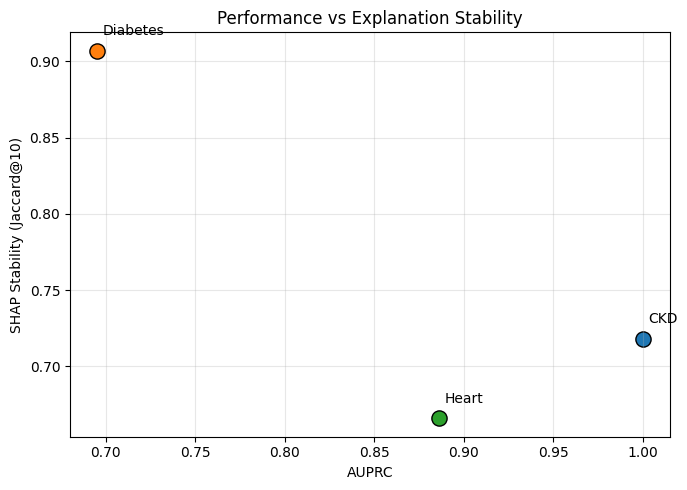

In [ ]:
plt.figure(figsize=(7, 5))

for _, row in stab_xgb.iterrows():
    plt.scatter(row["AUPRC_mean"], row["Jaccard_mean"], s=120, edgecolor="black", label=row["dataset"])

for _, row in stab_xgb.iterrows():
    plt.text(row["AUPRC_mean"] + 0.003, row["Jaccard_mean"] + 0.01, row["dataset"], fontsize=10)

plt.xlabel("AUPRC")
plt.ylabel("SHAP Stability (Jaccard@10)")
plt.title("Performance vs Explanation Stability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("performance_vs_stability.png", dpi=300, bbox_inches="tight")
plt.show()

# Section 7. NSGA-II Optimization

Install + imports

In [ ]:
!pip -q install pymoo==0.6.1.3

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Tuple, List

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate
from sklearn.metrics import average_precision_score
from sklearn.base import clone

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 19.7 MB/s eta 0:00:00


In [ ]:
# =========================
# PHASE-3 TARGET DATASET
# =========================
OPT_DATASET = "Diabetes"   # Start with "Diabetes" first
OPT_CFG = best_xgb_only[best_xgb_only["dataset"] == OPT_DATASET].iloc[0].to_dict()

print("Optimization dataset:", OPT_DATASET)
print("Chosen config:", OPT_CFG)

Optimization dataset: Diabetes
Chosen config: {'dataset': 'Diabetes', 'encoding': 'woe', 'balance': 'class_weight', 'dr': 'none', 'model': 'xgb', 'AUROC_mean': 0.8166342417889587, 'AUROC_std': 0.03168600527894458, 'AUPRC_mean': 0.6954006643683246, 'AUPRC_std': 0.05661053265414852, 'F1_mean': 0.6617659098163067, 'F1_std': 0.043064507765794346, 'BalAcc_mean': 0.7388378756114605, 'BalAcc_std': 0.03433899471463032}


In [ ]:


NSGA_CONFIG_FINAL = {
    "pop_size": 16,
    "n_gen": 8,
    "seed": RANDOM_STATE,
    "topk_shap": 10,
    "bootstrap_B": 4,
    "cv_splits": 3,
    "cv_repeats": 2,
    "max_features": None,
    "min_features": 2,
}

# Use final settings for reported results
NSGA_CONFIG = NSGA_CONFIG_FINAL.copy()
print("NSGA final config:", NSGA_CONFIG)


NSGA final config: {'pop_size': 16, 'n_gen': 8, 'seed': 42, 'topk_shap': 10, 'bootstrap_B': 4, 'cv_splits': 3, 'cv_repeats': 2, 'max_features': None, 'min_features': 2}


In [ ]:
def get_dataset_xy(name: str):
    X, y = DATASETS[name]
    X = X.copy()
    y = y.astype(int).copy()
    return X, y

def ensure_mask_valid(mask: np.ndarray, min_k=2, max_k=None):
    k = int(mask.sum())
    if k < min_k:
        # force-select random features
        idx = np.random.choice(len(mask), size=min_k, replace=False)
        mask[:] = 0
        mask[idx] = 1
    if max_k is not None and k > max_k:
        idx = np.where(mask == 1)[0]
        keep = np.random.choice(idx, size=max_k, replace=False)
        mask[:] = 0
        mask[keep] = 1
    return mask

In [ ]:
def eval_candidate_auprc(X, y, cfg, cols_subset):
    Xs = X[cols_subset]

    cv = RepeatedStratifiedKFold(
        n_splits=NSGA_CONFIG["cv_splits"],
        n_repeats=NSGA_CONFIG["cv_repeats"],
        random_state=RANDOM_STATE
    )

    pipe = build_full_pipeline(
        Xs, y,
        encoding=cfg["encoding"],
        balance=cfg["balance"],
        dr=cfg["dr"],
        model_name=cfg["model"]
    )

    scores = cross_validate(
        pipe, Xs, y,
        cv=cv,
        scoring={"auprc": auprc_scorer},   # your custom scorer (safe)
        n_jobs=-1,
        return_train_score=False
    )["test_auprc"]

    return float(np.mean(scores)), float(np.std(scores))

SHAP stability for a given feature subset (bootstrap + Jaccard@K)

In [ ]:
def shap_stability_for_subset(X, y, cfg, cols_subset, topk=10, B=8, sample_n=200):
    Xs = X[cols_subset].copy()

    # Fixed split so stability is measured consistently
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_idx, _ = next(skf.split(Xs, y))
    X_train = Xs.iloc[train_idx]
    y_train = y.iloc[train_idx]

    rng = np.random.RandomState(RANDOM_STATE)
    top_sets = []

    for b in range(B):
        boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        Xb = X_train.iloc[boot_idx]
        yb = y_train.iloc[boot_idx]

        pipe = build_full_pipeline(
            Xb, yb,
            encoding=cfg["encoding"],
            balance=cfg["balance"],
            dr=cfg["dr"],
            model_name=cfg["model"]
        )
        pipe.fit(Xb, yb)

        samp_idx = rng.choice(len(Xb), size=min(sample_n, len(Xb)), replace=False)
        top_idx, _ = get_shap_topk(pipe, Xb.iloc[samp_idx], topk=topk)
        top_sets.append(top_idx)

    J = []
    for i in range(len(top_sets)):
        for j in range(i+1, len(top_sets)):
            J.append(jaccard(top_sets[i], top_sets[j]))

    return float(np.mean(J)) if len(J) else 0.0

Build the NSGA-II problem

In [ ]:
class FeatureNSGAProblem(Problem):
    def __init__(self, X, y, cfg, feature_names):
        self.X = X
        self.y = y
        self.cfg = cfg
        self.feature_names = feature_names
        n_var = len(feature_names)

        super().__init__(
            n_var=n_var,
            n_obj=4,
            n_constr=0,
            xl=0,
            xu=1,
            type_var=np.bool_
        )

    def _evaluate(self, X_pop, out, *args, **kwargs):
        F = []
        for mask in X_pop:
            mask = mask.astype(int).copy()
            mask = ensure_mask_valid(mask, min_k=NSGA_CONFIG["min_features"], max_k=NSGA_CONFIG["max_features"])
            cols = [self.feature_names[i] for i in np.where(mask == 1)[0]]

            auprc_mean, auprc_std = eval_candidate_auprc(self.X, self.y, self.cfg, cols)

            # stability objective (higher is better) -> we minimize (1 - stability)
            stab = shap_stability_for_subset(
                self.X, self.y, self.cfg, cols,
                topk=NSGA_CONFIG["topk_shap"],
                B=NSGA_CONFIG["bootstrap_B"]
            )

            sparsity_ratio = len(cols) / len(self.feature_names)

            f1 = 1.0 - auprc_mean
            f2 = sparsity_ratio
            f3 = 1.0 - stab
            f4 = auprc_std

            F.append([f1, f2, f3, f4])

        out["F"] = np.array(F, dtype=float)

Run NSGA-II for each dataset (using best configs you already computed)

In [ ]:
def run_nsga_for_dataset(dataset_name: str, best_cfg_row: pd.DataFrame):
    X, y = get_dataset_xy(dataset_name)

    # dataset-aware search constraints
    if dataset_name == "Diabetes":
        NSGA_CONFIG["min_features"] = 3
    elif dataset_name == "Heart":
        NSGA_CONFIG["min_features"] = 4
    elif dataset_name == "CKD":
        NSGA_CONFIG["min_features"] = 4

    NSGA_CONFIG["max_features"] = max(5, int(0.7 * X.shape[1]))

    cfg = best_cfg_row.iloc[0].to_dict()
    feature_names = list(X.columns)

    problem = FeatureNSGAProblem(X, y, cfg, feature_names)

    algorithm = NSGA2(
        pop_size=NSGA_CONFIG["pop_size"],
        sampling=BinaryRandomSampling(),
        crossover=TwoPointCrossover(prob=0.9),
        mutation=BitflipMutation(prob=0.05),
        eliminate_duplicates=True
    )

    termination = get_termination("n_gen", NSGA_CONFIG["n_gen"])

    res = minimize(
        problem,
        algorithm,
        termination,
        seed=NSGA_CONFIG["seed"],
        save_history=False,
        verbose=True
    )
    return res, cfg, feature_names

# Run reported NSGA-II optimization across all datasets
nsga_results = {}
for dataset_name in ["Diabetes", "Heart", "CKD"]:
    cfg_row = best_xgb_only[best_xgb_only["dataset"] == dataset_name]
    print(f"\n===== NSGA-II on {dataset_name} =====")
    res, cfg, feats = run_nsga_for_dataset(dataset_name, cfg_row)
    nsga_results[dataset_name] = {"res": res, "cfg": cfg, "feats": feats}

print("NSGA-II runs completed for all datasets.")



===== NSGA-II on Diabetes =====
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       15 |      5 |             - |             -
     2 |       31 |      9 |  0.1292875626 |         ideal
     3 |       47 |     14 |  0.0799097417 |             f
     4 |       63 |     15 |  0.0166159482 |             f
     5 |       79 |     16 |  0.0788777214 |         nadir
     6 |       95 |     16 |  0.0166851880 |             f
     7 |      111 |     16 |  0.0228483857 |             f
     8 |      127 |     16 |  0.0053978222 |             f

===== NSGA-II on Heart =====
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       16 |     10 |             - |             -
     2 |       32 |     14 |  0.1224804304 |         ideal
     3 |       48 |     16 |  0.1101434125 |         ideal
     4 |       64 |     12 |  0.0161576266 |         ideal
     5 |       80 |     16 |  0.1785714286 |         nadir
     6 |       96 |     16 |  0.2285425586 |        

### Extract Pareto front, knee-point solution, and final optimization summary

In [ ]:
def select_knee_solution(F):
    F = np.array(F, dtype=float)
    Fmin = F.min(axis=0)
    Fmax = F.max(axis=0)
    Fn = (F - Fmin) / (Fmax - Fmin + 1e-12)
    d = np.linalg.norm(Fn, axis=1)
    knee_idx = int(np.argmin(d))
    return knee_idx, d[knee_idx]

def decode_mask(mask, feature_names):
    idx = np.where(mask.astype(int) == 1)[0]
    return [feature_names[i] for i in idx]

summary_rows = []
for ds, obj in nsga_results.items():
    res = obj["res"]
    F = res.F
    Xpop = res.X
    feats = obj["feats"]

    knee_idx, knee_dist = select_knee_solution(F)
    knee_mask = Xpop[knee_idx]
    knee_cols = decode_mask(knee_mask, feats)

    X, y = get_dataset_xy(ds)
    auprc_mean, auprc_std = eval_candidate_auprc(X, y, obj["cfg"], knee_cols)
    stab = shap_stability_for_subset(
        X, y, obj["cfg"], knee_cols,
        topk=NSGA_CONFIG["topk_shap"],
        B=NSGA_CONFIG["bootstrap_B"]
    )

    summary_rows.append({
        "dataset": ds,
        "selected_n_features": len(knee_cols),
        "AUPRC_mean": auprc_mean,
        "AUPRC_std": auprc_std,
        "SHAP_Jaccard": stab,
        "knee_distance": knee_dist,
        "selected_features": knee_cols
    })

nsga_summary = pd.DataFrame(summary_rows).sort_values("dataset")
display(nsga_summary)

nsga_summary.to_csv("nsga_summary_all_datasets.csv", index=False)
print("Saved nsga_summary_all_datasets.csv")


,dataset,selected_n_features,AUPRC_mean,AUPRC_std,SHAP_Jaccard,knee_distance,selected_features
2,CKD,6,0.998518,0.000440,1.000000,0.294194,"[sg, al, su, rbc, rc, cad]"
0,Diabetes,3,0.642108,0.028154,1.000000,0.490271,"[Glucose, BloodPressure, Age]"
1,Heart,5,0.871788,0.007316,0.909091,0.436430,"[age, restecg, exang, ca, thal]"


Saved nsga_summary_all_datasets.csv


Feature frequency across datasets

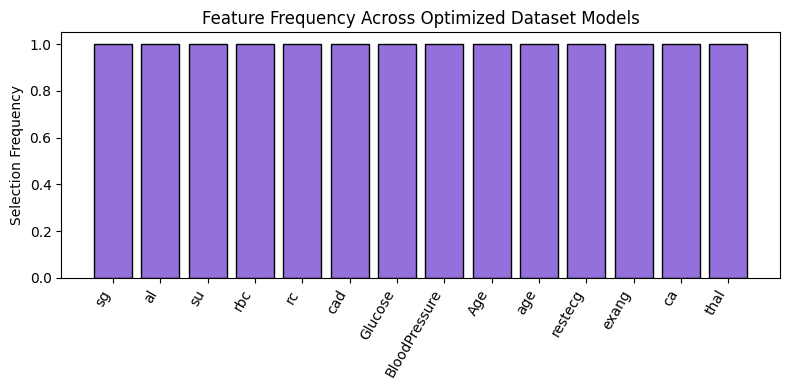

In [ ]:
from collections import Counter

feature_counter = Counter()
for _, row in nsga_summary.iterrows():
    for f in row["selected_features"]:
        feature_counter[f] += 1

feat_df = pd.DataFrame(feature_counter.items(), columns=["feature", "count"])
feat_df = feat_df.sort_values("count", ascending=False)

plt.figure(figsize=(8,4))
plt.bar(feat_df["feature"], feat_df["count"], color="mediumpurple", edgecolor="black")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Selection Frequency")
plt.title("Feature Frequency Across Optimized Dataset Models")
plt.tight_layout()
plt.savefig("feature_frequency_across_datasets.png", dpi=300)
plt.show()

Optimized Performance Summary (After applying NSGA-II)

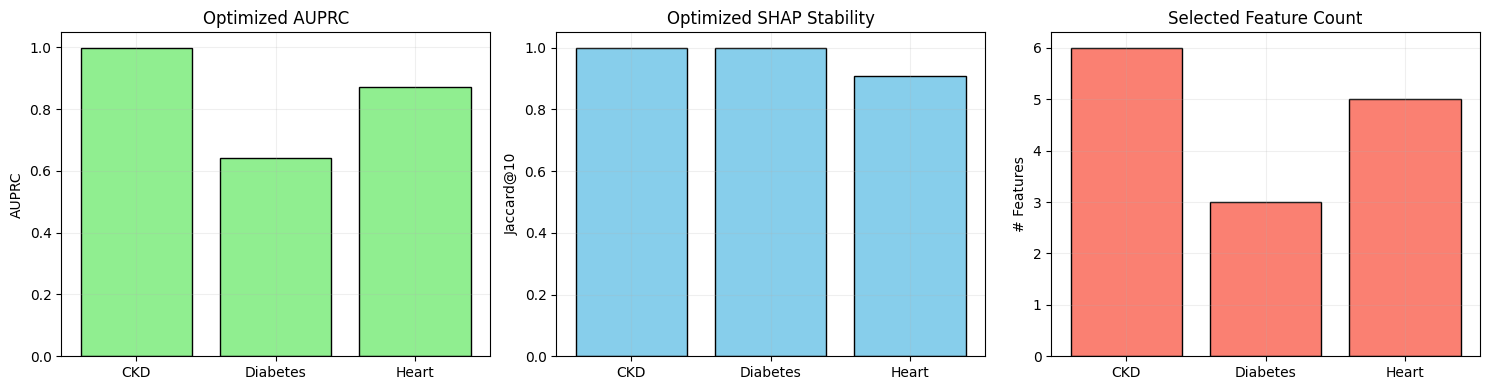

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Performance
axes[0].bar(nsga_summary["dataset"], nsga_summary["AUPRC_mean"], color="lightgreen", edgecolor="black")
axes[0].set_title("Optimized AUPRC")
axes[0].set_ylabel("AUPRC")
axes[0].grid(alpha=0.2)

# Stability
axes[1].bar(nsga_summary["dataset"], nsga_summary["SHAP_Jaccard"], color="skyblue", edgecolor="black")
axes[1].set_title("Optimized SHAP Stability")
axes[1].set_ylabel("Jaccard@10")
axes[1].grid(alpha=0.2)

# Features
axes[2].bar(nsga_summary["dataset"], nsga_summary["selected_n_features"], color="salmon", edgecolor="black")
axes[2].set_title("Selected Feature Count")
axes[2].set_ylabel("# Features")
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("project_update_summary.png", dpi=300, bbox_inches="tight")
plt.show()

Pareto fronts across datasets

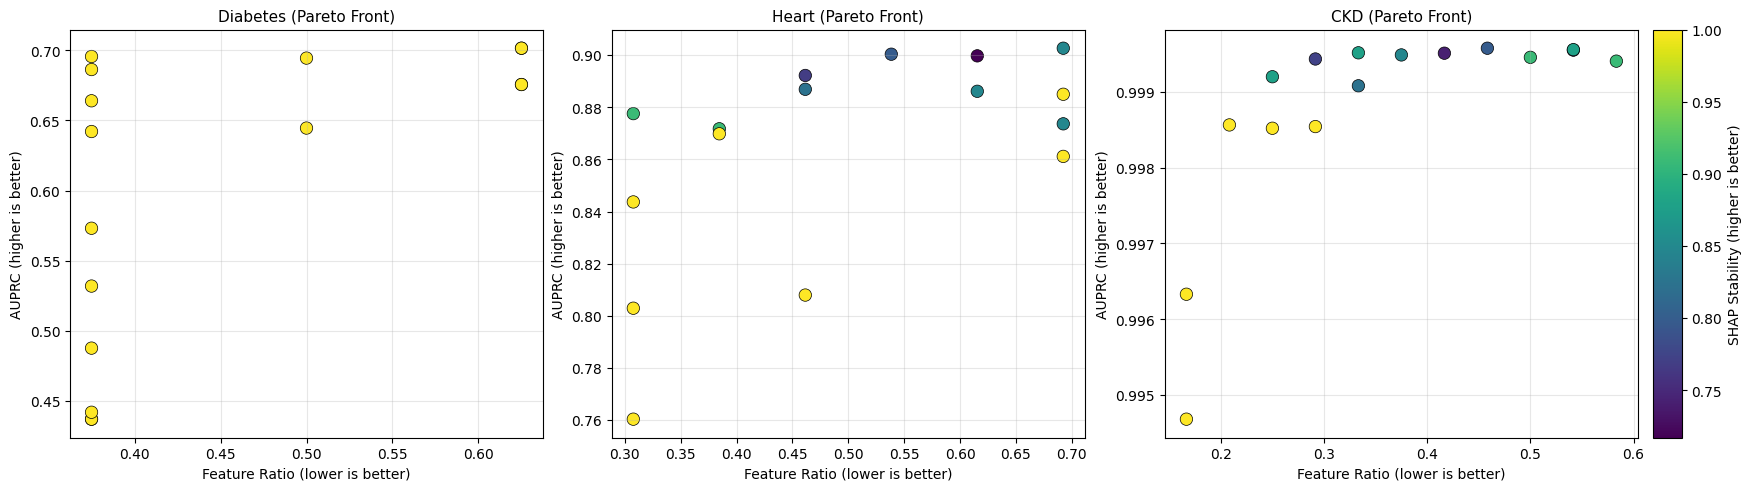

In [ ]:
# Figure: Pareto fronts across datasets

import matplotlib.pyplot as plt
import numpy as np

if "nsga_results" not in globals() or len(nsga_results) == 0:
    raise ValueError("nsga_results not found. Run the NSGA optimization block first.")

n_ds = len(nsga_results)

# Create a dedicated colorbar axis to avoid subplot misalignment
fig = plt.figure(figsize=(5.4 * n_ds + 1.2, 4.8), constrained_layout=True)
gs = fig.add_gridspec(1, n_ds + 1, width_ratios=[1] * n_ds + [0.06])

axes = [fig.add_subplot(gs[0, i]) for i in range(n_ds)]
cax = fig.add_subplot(gs[0, -1])

# Track global color limits for consistent color mapping
all_cvals = []
for _, obj in nsga_results.items():
    F = obj["res"].F
    all_cvals.extend(list(1 - F[:, 2]))

vmin = np.min(all_cvals)
vmax = np.max(all_cvals)

sc = None
for ax, (ds, obj) in zip(axes, nsga_results.items()):
    F = obj["res"].F

    x = F[:, 1]          # feature ratio
    y = 1 - F[:, 0]      # AUPRC
    c = 1 - F[:, 2]      # SHAP stability

    sc = ax.scatter(
        x, y,
        c=c,
        s=80,
        vmin=vmin,
        vmax=vmax,
        edgecolors="black",
        linewidths=0.5
    )

    ax.set_title(f"{ds} (Pareto Front)", fontsize=11)
    ax.set_xlabel("Feature Ratio (lower is better)")
    ax.set_ylabel("AUPRC (higher is better)")
    ax.grid(alpha=0.3)

# Shared colorbar
cb = fig.colorbar(sc, cax=cax)
cb.set_label("SHAP Stability (higher is better)")

#fig.suptitle("Pareto Fronts Across Datasets", fontsize=14, y=1.02)

plt.savefig("pareto_fronts_all_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

Sparsity vs Performance vs Stability


Final Optimization Table


,Dataset,SelectedFeatures,Optimized_AUPRC,Optimized_AUPRC_std,Optimized_Stability
2,CKD,6,0.998518,0.000440,1.000000
0,Diabetes,3,0.642108,0.028154,1.000000
1,Heart,5,0.871788,0.007316,0.909091


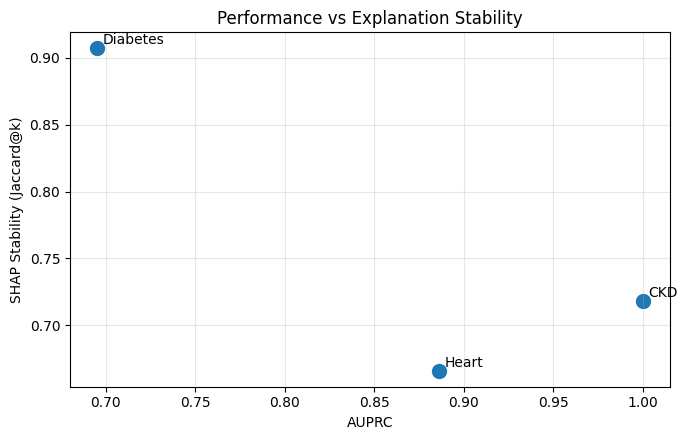

In [ ]:

# F1. Final compact summary tables

final_phase1_table = best_xgb_only[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean","AUPRC_std","BalAcc_mean"]].copy()
final_phase1_table.columns = ["Dataset","Encoding","Balance","DR","Model","AUROC","AUPRC","AUPRC_std","BalancedAcc"]

final_stability_table = stab_xgb[["dataset","AUPRC_mean","Jaccard_mean","Jaccard_std"]].copy()
final_stability_table.columns = ["Dataset","AUPRC","SHAP_Jaccard","SHAP_Jaccard_std"]

if "nsga_summary" in globals():
    final_nsga_table = nsga_summary[["dataset","selected_n_features","AUPRC_mean","AUPRC_std","SHAP_Jaccard"]].copy()
    final_nsga_table.columns = ["Dataset","SelectedFeatures","Optimized_AUPRC","Optimized_AUPRC_std","Optimized_Stability"]
else:
    final_nsga_table = pd.DataFrame()


#print("Final Summary of the performance Table")
#display(final_phase1_table)

#print("Final Stability Table")
#display(final_stability_table)

if len(final_nsga_table):
    print("Final Optimization Table")
    display(final_nsga_table)


final_phase1_table.to_csv("final_phase1_table.csv", index=False)
final_stability_table.to_csv("final_stability_table.csv", index=False)
if len(final_nsga_table):
    final_nsga_table.to_csv("final_nsga_table.csv", index=False)


# Figure: Performance vs explanation stability

import matplotlib.pyplot as plt

if "final_stability_table" not in globals() or final_stability_table.empty:
    raise ValueError("final_stability_table not found. Run F1 first.")

plt.figure(figsize=(7, 4.5))
plt.scatter(final_stability_table["AUPRC"], final_stability_table["SHAP_Jaccard"], s=100)

for _, row in final_stability_table.iterrows():
    plt.text(row["AUPRC"] + 0.003, row["SHAP_Jaccard"] + 0.003, row["Dataset"])

plt.title("Performance vs Explanation Stability")
plt.xlabel("AUPRC")
plt.ylabel("SHAP Stability (Jaccard@k)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("performance_vs_stability.png", dpi=300, bbox_inches="tight")
plt.show()

Optional: table image for slides

# Section 8. Ensemble Learning Extension (with baseline)

In [ ]:
# =========================
# B1. Ensemble model support (
# Covers:
# - boosting: XGBoost, LightGBM
# - voting: soft voting
# - stacking: stacked generalization
# - bagging: explicit bagged decision tree
# =========================

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

# -------------------------
# Helper: safe SMOTE
# -------------------------
def safe_smote(y, random_state=42):
    """
    Create a SMOTE object with a fold-safe k_neighbors value.
    This avoids crashes when the minority class is small in a CV fold.
    """
    y_arr = np.asarray(y)
    _, counts = np.unique(y_arr, return_counts=True)
    minority_count = counts.min()

    if minority_count <= 1:
        return None

    k = min(3, minority_count - 1)
    return SMOTE(random_state=random_state, k_neighbors=k)

# -------------------------
# Ensemble builders
# -------------------------
def build_ensemble(model_name: str):
    # Boosting-family learners
    xgb = XGBClassifier(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    )

    lgbm_model = lgb.LGBMClassifier(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    lr_meta = LogisticRegression(max_iter=5000, solver="liblinear")

    # Explicit bagging family representative
    if model_name == "bag_dt":
        return BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    # Soft voting ensemble
    if model_name == "vote_xgb_lgbm_lr":
        return VotingClassifier(
            estimators=[("xgb", xgb), ("lgbm", lgbm_model), ("lr", lr_meta)],
            voting="soft",
            n_jobs=-1
        )

    # Stacking ensemble
    if model_name == "stack_xgb_lgbm_lr":
        return StackingClassifier(
            estimators=[("xgb", xgb), ("lgbm", lgbm_model), ("lr", lr_meta)],
            final_estimator=LogisticRegression(max_iter=5000, solver="liblinear"),
            stack_method="predict_proba",
            passthrough=False,
            cv=5,
            n_jobs=-1
        )

    raise ValueError(f"Unknown ensemble model: {model_name}")

# -------------------------
# Extended model getter
# -------------------------
def get_model_extended(model_name: str):
    if model_name in ["bag_dt", "vote_xgb_lgbm_lr", "stack_xgb_lgbm_lr"]:
        return build_ensemble(model_name)
    return get_model(model_name)

# -------------------------
# Extended pipeline
# -------------------------
def build_full_pipeline_extended(X, y, encoding="woe", balance="smote", dr="none", model_name="xgb"):
    # Scaling mainly helpful for LR / LDA
    scale_numeric = True if (model_name in ["lr"] or dr == "lda") else False
    pre = build_preprocessor(X, encoding=encoding, scale_numeric=scale_numeric)
    steps = [("prep", pre)]

    dr_step = maybe_add_dim_reduction(dr)
    if dr_step is not None:
        steps.append(dr_step)

    if balance == "smote":
        sm = safe_smote(y, random_state=RANDOM_STATE)
        if sm is not None:
            steps.append(("smote", sm))
    elif balance == "class_weight":
        pass
    elif balance == "none":
        pass
    else:
        raise ValueError("balance must be 'smote' or 'class_weight' or 'none'")

    clf = get_model_extended(model_name)

    # Apply class-weight handling only to compatible single models
    if balance == "class_weight":
        if model_name in ["lr", "rf"]:
            clf.set_params(class_weight="balanced")
        elif model_name == "xgb":
            pos = (y == 1).sum()
            neg = (y == 0).sum()
            if pos > 0:
                clf.set_params(scale_pos_weight=float(neg / pos))
        elif model_name == "lgbm":
            clf.set_params(is_unbalance=True)

    steps.append(("clf", clf))
    return ImbPipeline(steps=steps)

# -------------------------
# Evaluation helper
# -------------------------
def eval_one_extended(dataset_name, X, y, encoding, balance, dr, model_name):
    pipe = build_full_pipeline_extended(
        X, y,
        encoding=encoding,
        balance=balance,
        dr=dr,
        model_name=model_name
    )

    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        "dataset": dataset_name,
        "encoding": encoding,
        "balance": balance,
        "dr": dr,
        "model": model_name,
        "AUROC_mean": np.mean(scores["test_auroc"]),
        "AUROC_std":  np.std(scores["test_auroc"]),
        "AUPRC_mean": np.mean(scores["test_auprc"]),
        "AUPRC_std":  np.std(scores["test_auprc"]),
        "F1_mean":    np.mean(scores["test_f1"]),
        "F1_std":     np.std(scores["test_f1"]),
        "BalAcc_mean": np.mean(scores["test_bal_acc"]),
        "BalAcc_std":  np.std(scores["test_bal_acc"]),
    }
    return row

# -------------------------
# Run ensemble-family comparison
# -------------------------
ensemble_rows = []

for dname, (X, y) in DATASETS.items():
    # Use shared XGB protocol preprocessing for fair comparison
    cfg_row = shared_xgb_protocol[shared_xgb_protocol["dataset"] == dname].iloc[0]
    enc, bal, dr = cfg_row["encoding"], cfg_row["balance"], cfg_row["dr"]

    ensemble_rows.append(eval_one_extended(dname, X, y, enc, bal, dr, "bag_dt"))
    ensemble_rows.append(eval_one_extended(dname, X, y, enc, bal, dr, "vote_xgb_lgbm_lr"))
    ensemble_rows.append(eval_one_extended(dname, X, y, enc, bal, dr, "stack_xgb_lgbm_lr"))

ensemble_results = pd.DataFrame(ensemble_rows).sort_values(
    ["dataset", "AUPRC_mean"], ascending=[True, False]
)

print("Ensemble extension results:")
display(
    ensemble_results[
        ["dataset", "encoding", "balance", "dr", "model",
         "AUROC_mean", "AUPRC_mean", "AUPRC_std", "BalAcc_mean"]
    ]
)

ensemble_results.to_csv("ensemble_results.csv", index=False)

Ensemble extension results:


,dataset,encoding,balance,dr,model,AUROC_mean,AUPRC_mean,AUPRC_std,BalAcc_mean
8,CKD,woe,class_weight,none,stack_xgb_lgbm_lr,0.999893,0.999937,0.000144,0.991333
7,CKD,woe,class_weight,none,vote_xgb_lgbm_lr,0.999867,0.999922,0.000157,0.991200
6,CKD,woe,class_weight,none,bag_dt,0.996627,0.997495,0.004783,0.979733
3,Diabetes,woe,class_weight,none,bag_dt,0.836627,0.724463,0.053815,0.719779
5,Diabetes,woe,class_weight,none,stack_xgb_lgbm_lr,0.829944,0.717278,0.046276,0.714199
4,Diabetes,woe,class_weight,none,vote_xgb_lgbm_lr,0.824293,0.704288,0.044818,0.720561
2,Heart,onehot,smote,none,stack_xgb_lgbm_lr,0.912088,0.911390,0.034940,0.837152
1,Heart,onehot,smote,none,vote_xgb_lgbm_lr,0.903664,0.902273,0.033465,0.819088
0,Heart,onehot,smote,none,bag_dt,0.895530,0.893382,0.041393,0.812840


Ensemble comparison figure + final comparison figure

In [ ]:

# F1. Final compact summary tables

final_phase1_table = best_xgb_only[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean","AUPRC_std","BalAcc_mean"]].copy()
final_phase1_table.columns = ["Dataset","Encoding","Balance","DR","Model","AUROC","AUPRC","AUPRC_std","BalancedAcc"]

final_stability_table = stab_xgb[["dataset","AUPRC_mean","Jaccard_mean","Jaccard_std"]].copy()
final_stability_table.columns = ["Dataset","AUPRC","SHAP_Jaccard","SHAP_Jaccard_std"]

if "nsga_summary" in globals():
    final_nsga_table = nsga_summary[["dataset","selected_n_features","AUPRC_mean","AUPRC_std","SHAP_Jaccard"]].copy()
    final_nsga_table.columns = ["Dataset","SelectedFeatures","Optimized_AUPRC","Optimized_AUPRC_std","Optimized_Stability"]
else:
    final_nsga_table = pd.DataFrame()

if "ensemble_results" in globals():
    final_ensemble_table = ensemble_results[["dataset","model","AUPRC_mean","AUPRC_std","AUROC_mean"]].copy()
    final_ensemble_table.columns = ["Dataset","EnsembleModel","AUPRC","AUPRC_std","AUROC"]
else:
    final_ensemble_table = pd.DataFrame()

#print("Final Summary of the performance Table")
#display(final_phase1_table)

#print("Final Stability Table")
#display(final_stability_table)

#if len(final_nsga_table):
    #print("Final Optimization Table")
    #display(final_nsga_table)

#if len(final_ensemble_table):
    #print("Final Ensemble Table")
    #display(final_ensemble_table)

#final_phase1_table.to_csv("final_phase1_table.csv", index=False)
#final_stability_table.to_csv("final_stability_table.csv", index=False)
#if len(final_nsga_table):
    #final_nsga_table.to_csv("final_nsga_table.csv", index=False)
#if len(final_ensemble_table):
    #final_ensemble_table.to_csv("final_ensemble_table.csv", index=False)


Best ensemble per dataset:


,Dataset,EnsembleModel,AUPRC,AUPRC_std,AUROC
0,CKD,stack_xgb_lgbm_lr,0.999937,0.000144,0.999893
1,Diabetes,bag_dt,0.724463,0.053815,0.836627
2,Heart,stack_xgb_lgbm_lr,0.911390,0.034940,0.912088


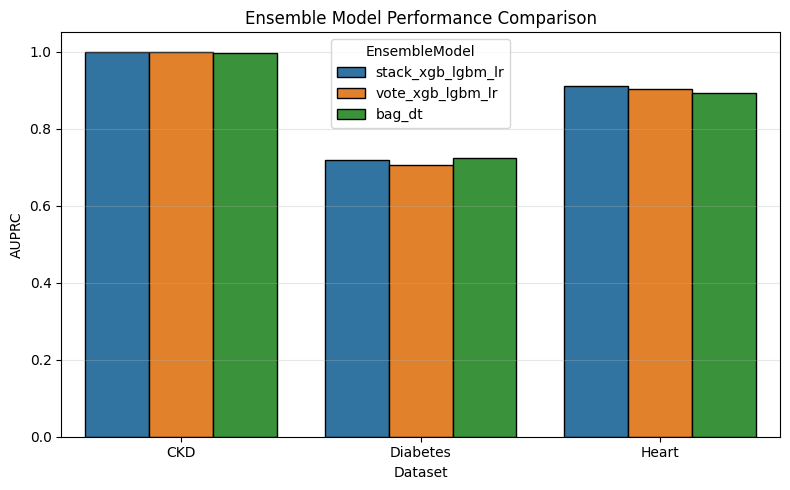

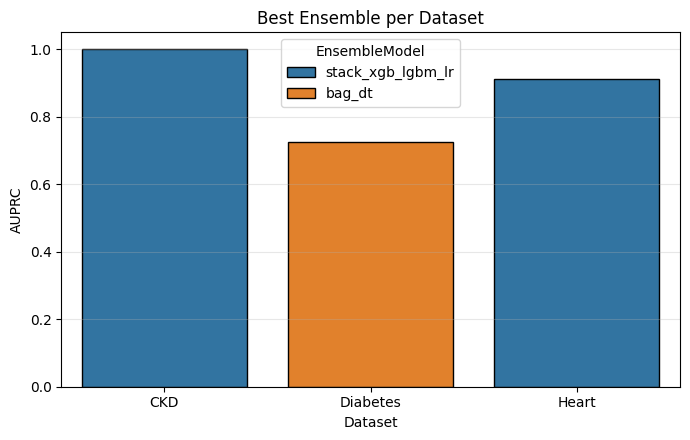

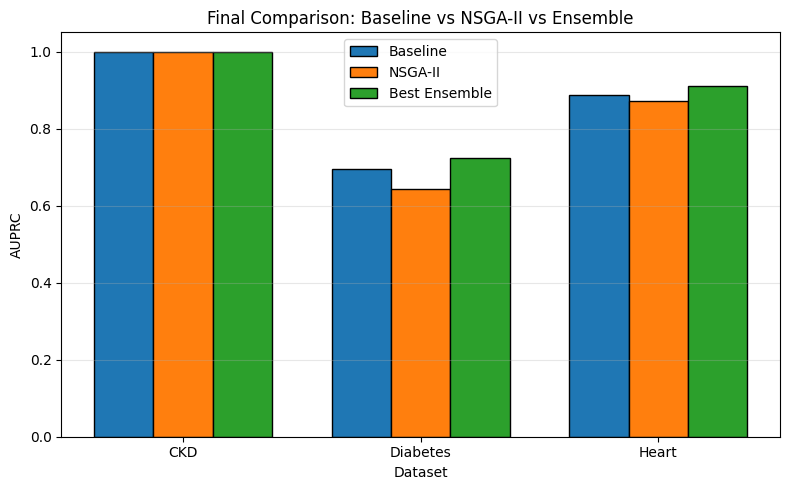

Main comparison table:


,Dataset,Baseline_AUPRC,NSGA_AUPRC,Best_Ensemble_AUPRC,NSGA_Selected_Features,NSGA_Stability,Best_Ensemble_Model
0,CKD,1.000000,0.998518,0.999937,6,1.000000,stack_xgb_lgbm_lr
1,Diabetes,0.695401,0.642108,0.724463,3,1.000000,bag_dt
2,Heart,0.886260,0.871788,0.911390,5,0.909091,stack_xgb_lgbm_lr


In [ ]:
# B2. Ensemble comparison figure + final comparison figure

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --------------------------------------------------
# STEP 0: Validate required final tables
# --------------------------------------------------
if "final_ensemble_table" not in globals() or final_ensemble_table.empty:
    raise ValueError("final_ensemble_table not found. Run F1 final summary tables first.")

if "final_phase1_table" not in globals() or final_phase1_table.empty:
    raise ValueError("final_phase1_table not found. Run F1 final summary tables first.")

if "final_nsga_table" not in globals() or final_nsga_table.empty:
    raise ValueError("final_nsga_table not found. Run F1 final summary tables first.")

# --------------------------------------------------
# STEP 1: Keep best ensemble per dataset
# --------------------------------------------------
best_ensemble_per_dataset = (
    final_ensemble_table
    .sort_values(["Dataset", "AUPRC"], ascending=[True, False])
    .groupby("Dataset", as_index=False)
    .first()
    .sort_values("Dataset")
    .reset_index(drop=True)
)

print("Best ensemble per dataset:")
display(best_ensemble_per_dataset)

# --------------------------------------------------
# STEP 2: Ensemble comparison figure
# --------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(
    data=final_ensemble_table,
    x="Dataset",
    y="AUPRC",
    hue="EnsembleModel",
    edgecolor="black"
)
plt.title("Ensemble Model Performance Comparison")
plt.ylabel("AUPRC")
plt.xlabel("Dataset")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("ensemble_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# STEP 3: Best ensemble per dataset figure
# --------------------------------------------------
plt.figure(figsize=(7, 4.5))
sns.barplot(
    data=best_ensemble_per_dataset,
    x="Dataset",
    y="AUPRC",
    hue="EnsembleModel",
    dodge=False,
    edgecolor="black"
)
plt.title("Best Ensemble per Dataset")
plt.ylabel("AUPRC")
plt.xlabel("Dataset")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("best_ensemble_per_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# STEP 4: Final comparison figure
# --------------------------------------------------
datasets = sorted(
    set(final_phase1_table["Dataset"])
    .intersection(set(final_nsga_table["Dataset"]))
    .intersection(set(best_ensemble_per_dataset["Dataset"]))
)

baseline_map = dict(zip(final_phase1_table["Dataset"], final_phase1_table["AUPRC"]))
nsga_map = dict(zip(final_nsga_table["Dataset"], final_nsga_table["Optimized_AUPRC"]))
ensemble_map = dict(zip(best_ensemble_per_dataset["Dataset"], best_ensemble_per_dataset["AUPRC"]))

baseline = [baseline_map[d] for d in datasets]
nsga = [nsga_map[d] for d in datasets]
ensemble = [ensemble_map[d] for d in datasets]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, baseline, width, label="Baseline", edgecolor="black")
plt.bar(x, nsga, width, label="NSGA-II", edgecolor="black")
plt.bar(x + width, ensemble, width, label="Best Ensemble", edgecolor="black")

plt.xticks(x, datasets)
plt.ylabel("AUPRC")
plt.xlabel("Dataset")
plt.title("Final Comparison: Baseline vs NSGA-II vs Ensemble")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# STEP 5: Manuscript-ready main comparison table
# --------------------------------------------------
feat_map = dict(zip(final_nsga_table["Dataset"], final_nsga_table["SelectedFeatures"]))
stab_map = dict(zip(final_nsga_table["Dataset"], final_nsga_table["Optimized_Stability"]))
ens_model_map = dict(zip(best_ensemble_per_dataset["Dataset"], best_ensemble_per_dataset["EnsembleModel"]))

main_results_table = pd.DataFrame({
    "Dataset": datasets,
    "Baseline_AUPRC": baseline,
    "NSGA_AUPRC": nsga,
    "Best_Ensemble_AUPRC": ensemble,
    "NSGA_Selected_Features": [int(feat_map[d]) for d in datasets],
    "NSGA_Stability": [float(stab_map[d]) for d in datasets],
    "Best_Ensemble_Model": [ens_model_map[d] for d in datasets]
})

print("Main comparison table:")
display(main_results_table)
main_results_table.to_csv("main_results_table.csv", index=False)


## Section 9. Final Summary Tables/ Figures


## Calibration and Reliability Analysis

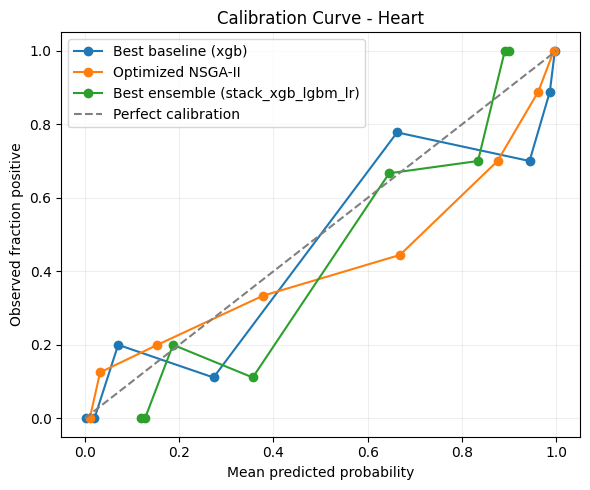

Calibration/Brier table - Heart


,Model,Brier
2,Best ensemble (stack_xgb_lgbm_lr),0.104261
0,Best baseline (xgb),0.119581
1,Optimized NSGA-II,0.147353


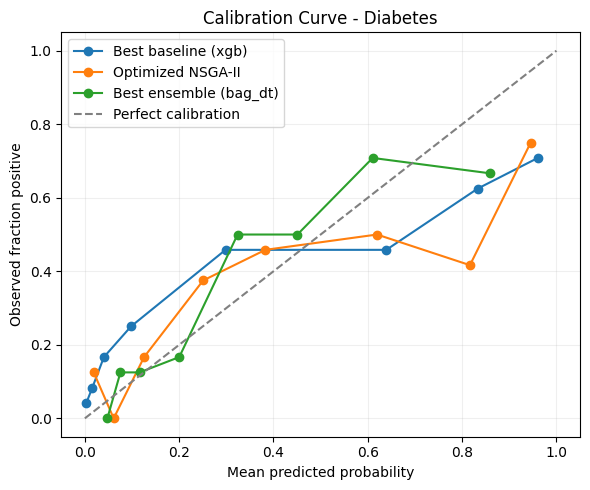

Calibration/Brier table - Diabetes


,Model,Brier
2,Best ensemble (bag_dt),0.167529
0,Best baseline (xgb),0.196931
1,Optimized NSGA-II,0.203950


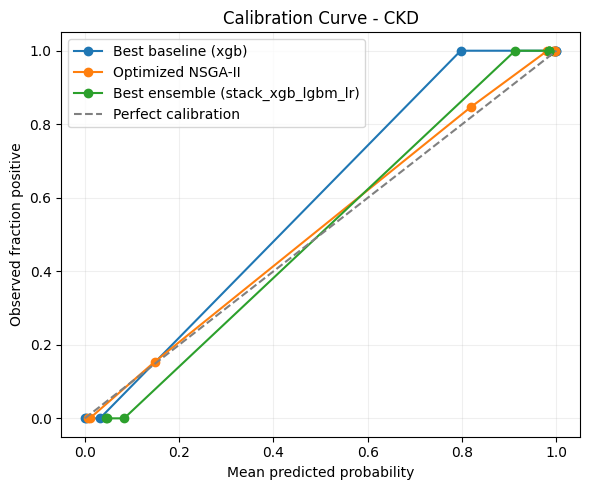

Calibration/Brier table - CKD


,Model,Brier
2,Best ensemble (stack_xgb_lgbm_lr),0.005017
0,Best baseline (xgb),0.010271
1,Optimized NSGA-II,0.021574


In [ ]:

# D1. Calibration utilities
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

def fit_config_pipeline(X, y, cfg_dict, cols_subset=None, extended=False):
    Xuse = X.copy() if cols_subset is None else X[cols_subset].copy()
    builder = build_full_pipeline_extended if extended else build_full_pipeline
    pipe = builder(
        Xuse, y,
        encoding=cfg_dict["encoding"],
        balance=cfg_dict["balance"],
        dr=cfg_dict["dr"],
        model_name=cfg_dict["model"]
    )
    pipe.fit(Xuse, y)
    return pipe, Xuse

def plot_calibration_for_dataset(dataset_name, use_ensemble_if_best=True):
    X, y = DATASETS[dataset_name]

    # Train/test split for visualization
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    # 1) best xgb-only
    cfg_best = best_xgb_only[best_xgb_only["dataset"] == dataset_name].iloc[0].to_dict()
    pipe_best = build_full_pipeline(Xtr, ytr, encoding=cfg_best["encoding"], balance=cfg_best["balance"], dr=cfg_best["dr"], model_name=cfg_best["model"])
    pipe_best.fit(Xtr, ytr)
    p_best = _get_scores_binary(pipe_best, Xte)

    # 2) optimized NSGA-II subset
    if "nsga_summary" in globals():
        row = nsga_summary[nsga_summary["dataset"] == dataset_name].iloc[0]
        selected_cols = row["selected_features"]
        pipe_nsga = build_full_pipeline(Xtr[selected_cols], ytr, encoding=cfg_best["encoding"], balance=cfg_best["balance"], dr=cfg_best["dr"], model_name=cfg_best["model"])
        pipe_nsga.fit(Xtr[selected_cols], ytr)
        p_nsga = _get_scores_binary(pipe_nsga, Xte[selected_cols])
    else:
        p_nsga = None

    # 3) ensemble extension (if available)
    p_ens = None
    ens_name = None
    if "ensemble_results" in globals():
        ens_df = ensemble_results[ensemble_results["dataset"] == dataset_name].sort_values("AUPRC_mean", ascending=False)
        if len(ens_df) > 0:
            cfg_ens = ens_df.iloc[0].to_dict()
            ens_name = cfg_ens["model"]
            pipe_ens = build_full_pipeline_extended(Xtr, ytr, encoding=cfg_ens["encoding"], balance=cfg_ens["balance"], dr=cfg_ens["dr"], model_name=cfg_ens["model"])
            pipe_ens.fit(Xtr, ytr)
            p_ens = _get_scores_binary(pipe_ens, Xte)

    plt.figure(figsize=(6,5))
    for probs, label in [(p_best, f"Best baseline ({cfg_best['model']})"),
                         (p_nsga, "Optimized NSGA-II"),
                         (p_ens, f"Best ensemble ({ens_name})" if ens_name else None)]:
        if probs is None or label is None:
            continue
        frac_pos, mean_pred = calibration_curve(yte, probs, n_bins=8, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker='o', label=label)

    plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Perfect calibration')
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed fraction positive")
    plt.title(f"Calibration Curve - {dataset_name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Brier scores
    rows = [{"Model": f"Best baseline ({cfg_best['model']})", "Brier": brier_score_loss(yte, p_best)}]
    if p_nsga is not None:
        rows.append({"Model": "Optimized NSGA-II", "Brier": brier_score_loss(yte, p_nsga)})
    if p_ens is not None:
        rows.append({"Model": f"Best ensemble ({ens_name})", "Brier": brier_score_loss(yte, p_ens)})
    return pd.DataFrame(rows).sort_values("Brier")

calibration_tables = {}
for ds in DATASETS.keys():
    calibration_tables[ds] = plot_calibration_for_dataset(ds)
    print(f"Calibration/Brier table - {ds}")
    display(calibration_tables[ds])



## Statistical Significance Testing

In [ ]:

# E1. Wilcoxon signed-rank comparisons
from scipy.stats import wilcoxon

def get_foldwise_auprc_scores(X, y, cfg_dict, cols_subset=None, extended=False):
    Xuse = X.copy() if cols_subset is None else X[cols_subset].copy()
    builder = build_full_pipeline_extended if extended else build_full_pipeline

    pipe = builder(
        Xuse, y,
        encoding=cfg_dict["encoding"],
        balance=cfg_dict["balance"],
        dr=cfg_dict["dr"],
        model_name=cfg_dict["model"]
    )
    scores = cross_validate(pipe, Xuse, y, cv=cv, scoring={"auprc": auprc_scorer}, n_jobs=-1)
    return scores["test_auprc"]

sig_rows = []
for ds in DATASETS.keys():
    X, y = DATASETS[ds]
    cfg_base = best_xgb_only[best_xgb_only["dataset"] == ds].iloc[0].to_dict()
    s_base = get_foldwise_auprc_scores(X, y, cfg_base, extended=False)

    # NSGA-II comparison
    if "nsga_summary" in globals():
        selected_cols = nsga_summary[nsga_summary["dataset"] == ds].iloc[0]["selected_features"]
        s_nsga = get_foldwise_auprc_scores(X, y, cfg_base, cols_subset=selected_cols, extended=False)
        stat, pval = wilcoxon(s_base, s_nsga, alternative="two-sided")
        sig_rows.append({"dataset": ds, "comparison": "Baseline XGB vs Optimized NSGA-II", "p_value": pval})

    # Ensemble comparison
    if "ensemble_results" in globals():
        ens_df = ensemble_results[ensemble_results["dataset"] == ds].sort_values("AUPRC_mean", ascending=False)
        if len(ens_df) > 0:
            cfg_ens = ens_df.iloc[0].to_dict()
            s_ens = get_foldwise_auprc_scores(X, y, cfg_ens, extended=True)
            stat2, pval2 = wilcoxon(s_base, s_ens, alternative="two-sided")
            sig_rows.append({"dataset": ds, "comparison": f"Baseline XGB vs {cfg_ens['model']}", "p_value": pval2})

significance_results = pd.DataFrame(sig_rows)
display(significance_results)
significance_results.to_csv("significance_results.csv", index=False)


,dataset,comparison,p_value
0,Heart,Baseline XGB vs Optimized NSGA-II,1.625359e-03
1,Heart,Baseline XGB vs stack_xgb_lgbm_lr,1.192093e-07
2,Diabetes,Baseline XGB vs Optimized NSGA-II,2.498031e-04
3,Diabetes,Baseline XGB vs bag_dt,3.290772e-04
4,CKD,Baseline XGB vs Optimized NSGA-II,2.622348e-04
5,CKD,Baseline XGB vs stack_xgb_lgbm_lr,4.393463e-03


## Final Performance/ Comparison Summary

In [ ]:

# F1. Final compact summary tables

final_phase1_table = best_xgb_only[["dataset","encoding","balance","dr","model","AUROC_mean","AUPRC_mean","AUPRC_std","BalAcc_mean"]].copy()
final_phase1_table.columns = ["Dataset","Encoding","Balance","DR","Model","AUROC","AUPRC","AUPRC_std","BalancedAcc"]

final_stability_table = stab_xgb[["dataset","AUPRC_mean","Jaccard_mean","Jaccard_std"]].copy()
final_stability_table.columns = ["Dataset","AUPRC","SHAP_Jaccard","SHAP_Jaccard_std"]

if "nsga_summary" in globals():
    final_nsga_table = nsga_summary[["dataset","selected_n_features","AUPRC_mean","AUPRC_std","SHAP_Jaccard"]].copy()
    final_nsga_table.columns = ["Dataset","SelectedFeatures","Optimized_AUPRC","Optimized_AUPRC_std","Optimized_Stability"]
else:
    final_nsga_table = pd.DataFrame()

if "ensemble_results" in globals():
    final_ensemble_table = ensemble_results[["dataset","model","AUPRC_mean","AUPRC_std","AUROC_mean"]].copy()
    final_ensemble_table.columns = ["Dataset","EnsembleModel","AUPRC","AUPRC_std","AUROC"]
else:
    final_ensemble_table = pd.DataFrame()

print("Final Summary of the performance Table")
display(final_phase1_table)

print("Final Stability Table")
display(final_stability_table)

if len(final_nsga_table):
    print("Final Optimization Table")
    display(final_nsga_table)

if len(final_ensemble_table):
    print("Final Ensemble Table")
    display(final_ensemble_table)

final_phase1_table.to_csv("final_phase1_table.csv", index=False)
final_stability_table.to_csv("final_stability_table.csv", index=False)
if len(final_nsga_table):
    final_nsga_table.to_csv("final_nsga_table.csv", index=False)
if len(final_ensemble_table):
    final_ensemble_table.to_csv("final_ensemble_table.csv", index=False)


Final Summary of the performance Table


,Dataset,Encoding,Balance,DR,Model,AUROC,AUPRC,AUPRC_std,BalancedAcc
32,CKD,woe,class_weight,none,xgb,1.000000,1.000000,4.440892e-17,0.996000
16,Diabetes,woe,class_weight,none,xgb,0.816634,0.695401,5.661053e-02,0.738838
12,Heart,onehot,smote,none,xgb,0.886573,0.886260,3.150156e-02,0.814116


Final Stability Table


,Dataset,AUPRC,SHAP_Jaccard,SHAP_Jaccard_std
0,CKD,1.000000,0.718208,0.082138
1,Diabetes,0.695401,0.907071,0.090887
2,Heart,0.886260,0.665964,0.117120


Final Optimization Table


,Dataset,SelectedFeatures,Optimized_AUPRC,Optimized_AUPRC_std,Optimized_Stability
2,CKD,6,0.998518,0.000440,1.000000
0,Diabetes,3,0.642108,0.028154,1.000000
1,Heart,5,0.871788,0.007316,0.909091


Final Ensemble Table


,Dataset,EnsembleModel,AUPRC,AUPRC_std,AUROC
8,CKD,stack_xgb_lgbm_lr,0.999937,0.000144,0.999893
7,CKD,vote_xgb_lgbm_lr,0.999922,0.000157,0.999867
6,CKD,bag_dt,0.997495,0.004783,0.996627
3,Diabetes,bag_dt,0.724463,0.053815,0.836627
5,Diabetes,stack_xgb_lgbm_lr,0.717278,0.046276,0.829944
4,Diabetes,vote_xgb_lgbm_lr,0.704288,0.044818,0.824293
2,Heart,stack_xgb_lgbm_lr,0.911390,0.034940,0.912088
1,Heart,vote_xgb_lgbm_lr,0.902273,0.033465,0.903664
0,Heart,bag_dt,0.893382,0.041393,0.895530
